In [1]:
import os
os.getcwd()

'/mnt/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM'

## In-silico screen

residue choices are made in `/home/achen918/catalytic_binders/251211_paper_revision_1/20_residue_SSM/choose_positions_making_ipd_blocks.ipynb`

and copied over to `/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/ssm.ipynb`


## AF3

In [4]:

import os
import json
from collections import defaultdict

# Define directories and file paths.
working_dir = '/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex'
input_fasta = os.path.join(working_dir, 'input/chainA_site_saturation.fasta')
json_dir = os.path.join(working_dir, 'json_files')
output_dir = os.path.join(working_dir, 'output')
command_file_path =  os.path.join(working_dir, 'af3')



def parse_fasta(fasta_file):
    """
    Parse a FASTA file where each entry has a single chain.
    Example header: >chainA_L22A

    Returns a dictionary mapping each header to its sequence.
    """
    sequences = {}
    current_header = None
    current_seq_lines = []

    with open(fasta_file, 'r') as f:
        for line in f:
            line = line.rstrip()
            if line.startswith('>'):
                # Save previous sequence if it exists
                if current_header is not None:
                    sequences[current_header] = ''.join(current_seq_lines)
                current_header = line[1:]  # remove '>'
                current_seq_lines = []
            else:
                current_seq_lines.append(line)
        # Save the last sequence
        if current_header is not None:
            sequences[current_header] = ''.join(current_seq_lines)

    return sequences


def main():   
    # File path for the command list output.
    command_file_path = os.path.join(working_dir, 'cmds_af3')

    # Ensure output directories exist.
    os.makedirs(json_dir, exist_ok=True)
    os.makedirs(output_dir, exist_ok=True)

    # Parse the FASTA file.
    fasta_entries = parse_fasta(input_fasta)
    
    pdb_data_list = []

    for i, (pdb_name, chain_A_seq) in enumerate(fasta_entries.items(), 1):
        # chain_A_seq is already the sequence string
        chain_B_seq = "ARILRVNFKI"  # fixed chain B

        total_len = len(chain_A_seq) + len(chain_B_seq) + 2  # +2 for ZnO

        pdb_data_list.append({
            "pdb_name": pdb_name,
            "chain_A_seq": chain_A_seq,
            "chain_B_seq": chain_B_seq,
            "total_len": total_len
        })

        if i % 100 == 0:
            print(f"Created pdb_data_list for {i} pdbs")


   


    # ============================
    # USER-DEFINED GROUP SIZE
    # ============================
    GROUP_SIZE = 400   # <–– change this as needed

    # ============================
    # Group PDBs by identical length
    # ============================
    length_groups = defaultdict(list)
    for pdb_data in pdb_data_list:
        length_groups[pdb_data["total_len"]].append(pdb_data)

    # ============================
    # Write JSONs + commands
    # ============================
    with open(command_file_path, 'w') as cmd_file:

        for length, pdbs_same_len in sorted(length_groups.items()):

            # chunk into GROUP_SIZE pieces
            for part_idx in range(0, len(pdbs_same_len), GROUP_SIZE):
                chunk = pdbs_same_len[part_idx : part_idx + GROUP_SIZE]

                # Build JSON list
                group_json = []
                for pdb_data in chunk:
                    group_json.append({
                        "name": pdb_data["pdb_name"],
                        "sequences": [
                            {"protein": {"id": "A", "sequence": pdb_data["chain_A_seq"],
                                         "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                            {"protein": {"id": "B", "sequence": pdb_data["chain_B_seq"],
                                         "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                            {"ligand":{"id":"C","smiles":"[Zn+2].O"}}
                        ],
                        "modelSeeds": [1],
                        "dialect": "alphafold3",
                        "version": 3
                    })

                # Generate JSON filename
                group_name = f"group_len{length}_part{part_idx//GROUP_SIZE + 1}.json"
                json_file_path = os.path.join(json_dir, group_name)

                # Write JSON
                with open(json_file_path, "w") as f_json:
                    json.dump(group_json, f_json, separators=(",", ":"))

                # Write sbatch command
                cmd = f"""
    ###CMD###
    #!/bin/bash

    echo "Running AlphaFold3 prediction for length {length}, batch part {part_idx//GROUP_SIZE + 1}..."
    /software/containers/users/ikalvet/mlfold3/mlfold3_01.sif python \
    /home/achen918/software/run_alphafold_custom.py \
            --json_path="{json_file_path}" \
            --output_dir="{output_dir}" \
            --run_data_pipeline=False \
            --buckets {length}
    """
                cmd_file.write(cmd)

            print(
                f"Created {len(pdbs_same_len)} PDBs of length {length}, "
                f"{(len(pdbs_same_len)-1)//GROUP_SIZE + 1} groups"
            )

    print(f"All commands saved to {command_file_path}")



if __name__ == '__main__':
    main()


Created pdb_data_list for 100 pdbs
Created pdb_data_list for 200 pdbs
Created pdb_data_list for 300 pdbs
Created 378 PDBs of length 191, 1 groups
All commands saved to /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex/cmds_af3


In [5]:
# Define directories and file paths.
working_dir = '/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex_wt'
input_fasta = os.path.join(working_dir, 'input/Zn45_WT.fa')
json_dir = os.path.join(working_dir, 'json_files')
output_dir = os.path.join(working_dir, 'output')
command_file_path =  os.path.join(working_dir, 'af3')


import os
import json
from collections import defaultdict

def parse_fasta(fasta_file):
    """
    Parse a FASTA file where each entry has a single chain.
    Example header: >chainA_L22A

    Returns a dictionary mapping each header to its sequence.
    """
    sequences = {}
    current_header = None
    current_seq_lines = []

    with open(fasta_file, 'r') as f:
        for line in f:
            line = line.rstrip()
            if line.startswith('>'):
                # Save previous sequence if it exists
                if current_header is not None:
                    sequences[current_header] = ''.join(current_seq_lines)
                current_header = line[1:]  # remove '>'
                current_seq_lines = []
            else:
                current_seq_lines.append(line)
        # Save the last sequence
        if current_header is not None:
            sequences[current_header] = ''.join(current_seq_lines)

    return sequences


def main():   
    # File path for the command list output.
    command_file_path = os.path.join(working_dir, 'cmds_af3')

    # Ensure output directories exist.
    os.makedirs(json_dir, exist_ok=True)
    os.makedirs(output_dir, exist_ok=True)

    # Parse the FASTA file.
    fasta_entries = parse_fasta(input_fasta)
    
    pdb_data_list = []

    for i, (pdb_name, chain_A_seq) in enumerate(fasta_entries.items(), 1):
        # chain_A_seq is already the sequence string
        chain_B_seq = "ARILRVNFKI"  # fixed chain B

        total_len = len(chain_A_seq) + len(chain_B_seq) + 2  # +2 for ZnO

        pdb_data_list.append({
            "pdb_name": pdb_name,
            "chain_A_seq": chain_A_seq,
            "chain_B_seq": chain_B_seq,
            "total_len": total_len
        })

        if i % 100 == 0:
            print(f"Created pdb_data_list for {i} pdbs")


   


    # ============================
    # USER-DEFINED GROUP SIZE
    # ============================
    GROUP_SIZE = 400   # <–– change this as needed

    # ============================
    # Group PDBs by identical length
    # ============================
    length_groups = defaultdict(list)
    for pdb_data in pdb_data_list:
        length_groups[pdb_data["total_len"]].append(pdb_data)

    # ============================
    # Write JSONs + commands
    # ============================
    with open(command_file_path, 'w') as cmd_file:

        for length, pdbs_same_len in sorted(length_groups.items()):

            # chunk into GROUP_SIZE pieces
            for part_idx in range(0, len(pdbs_same_len), GROUP_SIZE):
                chunk = pdbs_same_len[part_idx : part_idx + GROUP_SIZE]

                # Build JSON list
                group_json = []
                for pdb_data in chunk:
                    group_json.append({
                        "name": pdb_data["pdb_name"],
                        "sequences": [
                            {"protein": {"id": "A", "sequence": pdb_data["chain_A_seq"],
                                         "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                            {"protein": {"id": "B", "sequence": pdb_data["chain_B_seq"],
                                         "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                            {"ligand":{"id":"C","smiles":"[Zn+2].O"}}
                        ],
                        "modelSeeds": [1],
                        "dialect": "alphafold3",
                        "version": 3
                    })

                # Generate JSON filename
                group_name = f"group_len{length}_part{part_idx//GROUP_SIZE + 1}.json"
                json_file_path = os.path.join(json_dir, group_name)

                # Write JSON
                with open(json_file_path, "w") as f_json:
                    json.dump(group_json, f_json, separators=(",", ":"))

                # Write sbatch command
                cmd = f"""
    ###CMD###
    #!/bin/bash

    echo "Running AlphaFold3 prediction for length {length}, batch part {part_idx//GROUP_SIZE + 1}..."
    /software/containers/users/ikalvet/mlfold3/mlfold3_01.sif python \
    /home/achen918/software/run_alphafold_custom.py \
            --json_path="{json_file_path}" \
            --output_dir="{output_dir}" \
            --run_data_pipeline=False \
            --buckets {length}
    """
                cmd_file.write(cmd)

            print(
                f"Created {len(pdbs_same_len)} PDBs of length {length}, "
                f"{(len(pdbs_same_len)-1)//GROUP_SIZE + 1} groups"
            )

    print(f"All commands saved to {command_file_path}")



if __name__ == '__main__':
    main()


Created 1 PDBs of length 191, 1 groups
All commands saved to /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex_wt/cmds_af3


# AF3 analysis

# Collect folding metrics

In [6]:
import argparse
import os
import math
import glob

def create_slurm_script(script_path, output_act_dir, input_json_dir, combined_output_file, num_jobs, pdbs_per_job, log_dir):
    script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem=4g
#SBATCH -c 1
#SBATCH -J collect_data_job
#SBATCH -o {log_dir}/out.log%a
#SBATCH -t 01:00:00
#SBATCH -a 1-{num_jobs}

# Create a directory for individual CSV outputs
output_dir="{log_dir}/../parallel_csvs"
mkdir -p $output_dir


# Calculate start and end indices for this job
start_idx=$(( ($SLURM_ARRAY_TASK_ID - 1) * {pdbs_per_job} + 1 ))
end_idx=$(( $SLURM_ARRAY_TASK_ID * {pdbs_per_job} ))

# Run the Python script with the calculated indices
/software/containers/PPI_design.sif {script_path} "{output_act_dir}" "{input_json_dir}" $start_idx $end_idx "$output_dir/output_$SLURM_ARRAY_TASK_ID.csv"
"""
    return script

def main():
    scratch_dir = "/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM"
    working_dir = scratch_dir + "/af3_complex_analysis"
    combined_output_file = os.path.join(working_dir, 'af3_data.csv')
    output_act_dir = os.path.join(scratch_dir, 'af3_complex/output')
    input_json_dir = os.path.join(scratch_dir, 'af3_complex/json_files')
    
    log_dir = os.path.join(working_dir, "folding_out/logs")
    os.makedirs(log_dir, exist_ok=True)

    # Path to the Python script (collect_data.py)
    script_path = os.path.join(os.getcwd() + "/af3_complex_analysis", "collect_data.py")

    # Count total number of PDB files (one per folder in output_act_dir)
    num_pdbs = len([d for d in os.listdir(output_act_dir) if os.path.isdir(os.path.join(output_act_dir, d))])
    
    pdbs_per_job = 1000  # Change this value based on clusterstatus cpu usage, around 20 s/100 pdbs
    num_jobs = math.ceil(num_pdbs / pdbs_per_job)

    print(f"Found {num_pdbs} PDB folders. Splitting into {num_jobs} jobs with {pdbs_per_job} PDBs per job.")

    slurm_script_content = create_slurm_script(
        script_path=script_path,
        output_act_dir=output_act_dir,
        input_json_dir=input_json_dir, 
        combined_output_file=combined_output_file,
        num_jobs=num_jobs,
        pdbs_per_job=pdbs_per_job,
        log_dir=log_dir,
    )

    submit_script_path = os.path.join(os.getcwd() + "/af3_complex_analysis", "submit_collect_data.sh")
    
    with open(submit_script_path, "w") as f:
        f.write(slurm_script_content)

    print(f"SLURM submit script written to: {submit_script_path}")
    print(f"Submit your job with: sbatch {submit_script_path}")

main()


Found 379 PDB folders. Splitting into 1 jobs with 1000 PDBs per job.
SLURM submit script written to: /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex_analysis/submit_collect_data.sh
Submit your job with: sbatch /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/af3_complex_analysis/submit_collect_data.sh


## SSM plot 

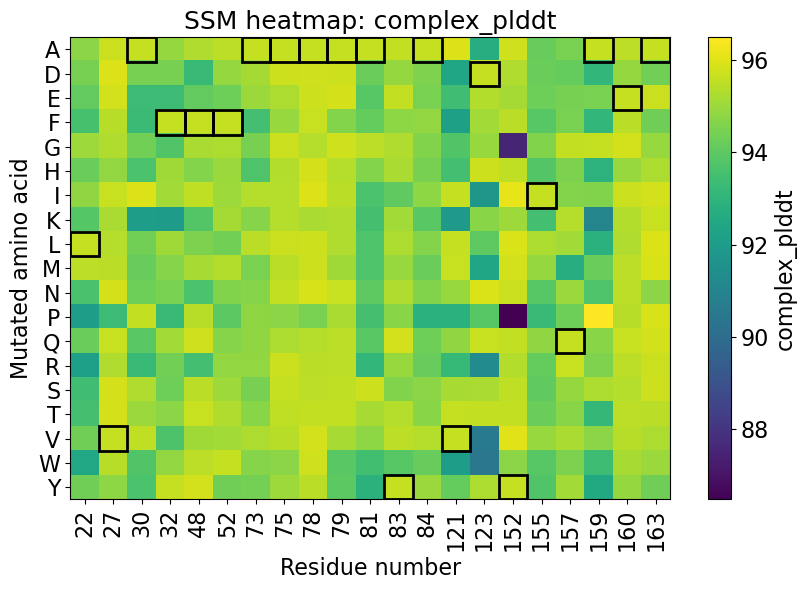

Saved: /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/ssm_plot/ssm_complex_plddt_heatmap.png


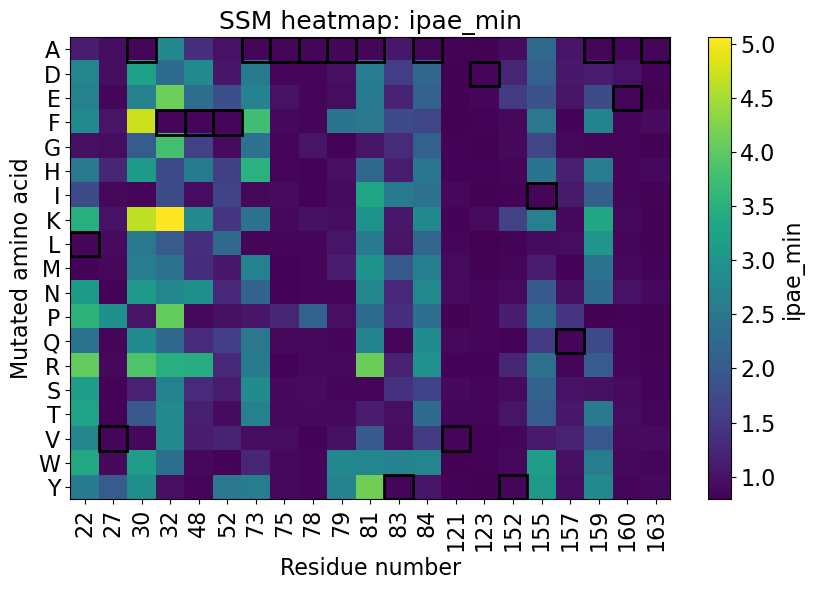

Saved: /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/ssm_plot/ssm_ipae_min_heatmap.png


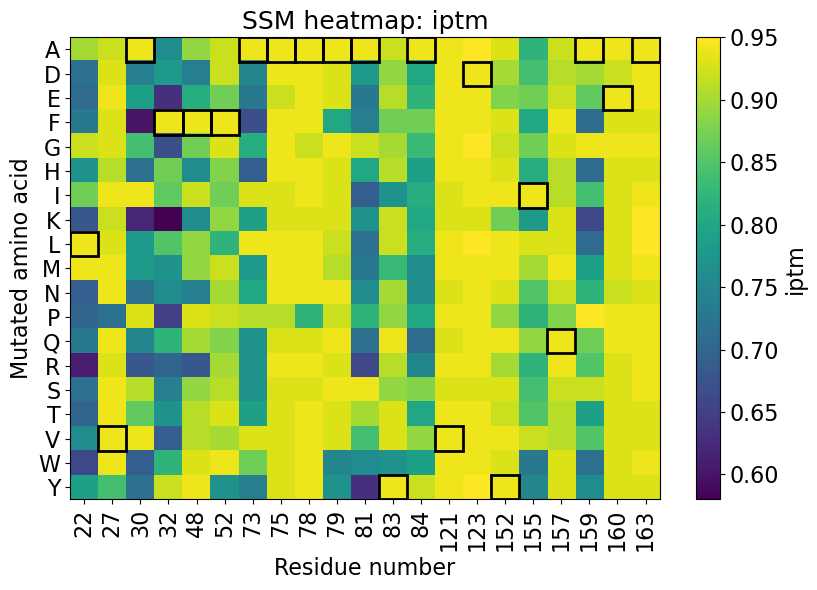

Saved: /home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/ssm_plot/ssm_iptm_heatmap.png


In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------------------
# Config
# ----------------------------
working_dir = '/home/achen918/catalytic_binders/251211_paper_revision_1/computational_SSM/'
input_csv   = os.path.join(working_dir, 'af3_complex_analysis', 'folding_out/af3_data.csv')
output_dir  = os.path.join(working_dir, 'ssm_plot')
os.makedirs(output_dir, exist_ok=True)

AA_ORDER = list("ADEFGHIKLMNPQRSTVWY")
METRICS = ["complex_plddt", "ipae_min", "iptm"]

mut_re = re.compile(r"^([A-Za-z])(\d+)([A-Za-z])$")


def build_heatmap_matrix(df, metric):
    df = df.copy()
    df["description"] = df["description"].astype(str).str.strip()

    wt_row = df[df["description"].str.lower() == "wt"]
    if wt_row.empty:
        raise ValueError("WT row (description == 'wt') not found")
    wt_val = float(wt_row.iloc[0][metric])

    mut_re = re.compile(r".*_([A-Za-z])(\d+)([A-Za-z])$", re.IGNORECASE)

    rows = []
    for _, r in df.iterrows():
        desc = r["description"]
        if desc.lower() == "wt":
            continue

        m = mut_re.match(desc)
        if m:
            wt_aa = m.group(1).upper()
            resi = int(m.group(2))
            mut_aa = m.group(3).upper()
            rows.append((wt_aa, resi, mut_aa, float(r[metric])))

    mut_df = pd.DataFrame(rows, columns=["wt_aa", "resi", "mut_aa", metric])


    residues = sorted(mut_df["resi"].unique())
    wt_letters = {r: mut_df[mut_df["resi"] == r]["wt_aa"].iloc[0] for r in residues}

    mat = np.full((len(AA_ORDER), len(residues)), np.nan)
    aa_to_i = {aa: i for i, aa in enumerate(AA_ORDER)}
    res_to_j = {r: j for j, r in enumerate(residues)}

    # fill mutants
    for _, r in mut_df.iterrows():
        mat[aa_to_i[r["mut_aa"]], res_to_j[r["resi"]]] = r[metric]

    # fill WT cells
    for r in residues:
        wt_aa = wt_letters[r]
        mat[aa_to_i[wt_aa], res_to_j[r]] = wt_val

    return residues, mat, wt_letters


def plot_heatmap(
    residues,
    mat,
    wt_letters,
    metric,
    title_fs=18,
    axis_label_fs=16,
    tick_label_fs=16,
    cbar_label_fs=16,
):
    fig_w = max(8, 0.4 * len(residues))
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    im = ax.imshow(mat, aspect="auto", interpolation="nearest")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric, fontsize=cbar_label_fs)
    cbar.ax.tick_params(labelsize=tick_label_fs)

    ax.set_yticks(range(len(AA_ORDER)))
    ax.set_yticklabels(AA_ORDER, fontsize=tick_label_fs)

    ax.set_xticks(range(len(residues)))
    ax.set_xticklabels(residues, rotation=90, fontsize=tick_label_fs)

    # ---- WT black boxes ----
    aa_to_i = {aa: i for i, aa in enumerate(AA_ORDER)}
    for j, resi in enumerate(residues):
        wt_aa = wt_letters[resi]
        i = aa_to_i[wt_aa]
        rect = patches.Rectangle(
            (j - 0.5, i - 0.5),
            1,
            1,
            linewidth=2,
            edgecolor="black",
            facecolor="none"
        )
        ax.add_patch(rect)

    wt_label = ", ".join([f"{r}({wt_letters[r]})" for r in residues])
    ax.set_title(
#        f"SSM heatmap: {metric}\nWT: {wt_label}",
        f"SSM heatmap: {metric}",
        fontsize=title_fs
    )

    ax.set_xlabel("Residue number", fontsize=axis_label_fs)
    ax.set_ylabel("Mutated amino acid", fontsize=axis_label_fs)

    plt.tight_layout()

    outpath = os.path.join(output_dir, f"ssm_{metric}_heatmap.png")
    plt.savefig(outpath, dpi=400)
    plt.show()

    print(f"Saved: {outpath}")


# ----------------------------
# Run
# ----------------------------
df = pd.read_csv(input_csv)

for metric in METRICS:
    residues, mat, wt_letters = build_heatmap_matrix(df, metric)
    plot_heatmap(residues, mat, wt_letters, metric)
